In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../names.txt','r').read().splitlines()

In [4]:
## creating characters vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y= [], []
    for w in words: 

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("'.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch. tensor(X)
    Y = torch. tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random. seed(42)
random. shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])            ## 80% for training
Xdev, Ydev = build_dataset(words[n1:n2])        ## 10% for development/validation
Xte, Yte = build_dataset(words[n2:])            ## 10% for testing

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [33]:

## Same code but more better structured 
n_embed = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g)
emb = C[Xtr]
w1 = torch.randn((n_embed*block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g)  
w2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.1
parameters = [C,w1,b1,w2,b2]
length = sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True

In [34]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ w1  + b1  # hidden layer pre-activation
    ## batch normalisation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ w2 + b2  # output layer (initial loss depens of w2 and b2 so lets update date)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break ## we are chcking the first loss value and as we can see it is really high 27.881, now if all the characters should have a same probability of coming next then 
## initial loss should be 3.29 somthing as 1/27 so now we will try to decrease the initail loss

      0/ 200000: 3.3234
  10000/ 200000: 2.1900
  20000/ 200000: 2.4356
  30000/ 200000: 2.6011
  40000/ 200000: 2.0351
  50000/ 200000: 2.4618
  60000/ 200000: 2.3861
  70000/ 200000: 2.1422
  80000/ 200000: 2.3436
  90000/ 200000: 2.1284
 100000/ 200000: 1.8044
 110000/ 200000: 2.1827
 120000/ 200000: 1.8520
 130000/ 200000: 2.4824
 140000/ 200000: 2.1851
 150000/ 200000: 2.1293
 160000/ 200000: 1.8834
 170000/ 200000: 1.8686
 180000/ 200000: 2.0562
 190000/ 200000: 1.8560


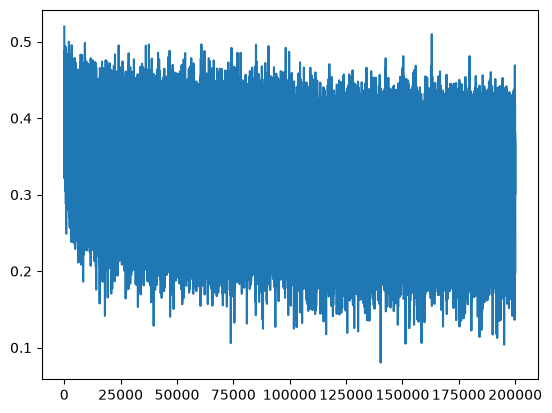

In [31]:
plt.plot(lossi)

In [32]:
h

tensor([[ 0.5311, -0.0765, -0.9835,  ..., -0.9963, -0.5151, -0.4085],
        [ 0.8575,  0.9685, -0.0432,  ..., -0.9999,  0.9732, -0.9605],
        [-0.8390, -0.8859, -0.9710,  ..., -0.2892, -0.9394, -0.9319],
        ...,
        [ 0.7182, -0.9001, -0.1488,  ...,  0.0421, -0.9968, -0.7148],
        [-0.9855, -0.9490,  0.9996,  ..., -0.9936, -0.8446,  0.9977],
        [ 0.9842,  0.7477, -0.9999,  ..., -0.9103, -0.8185, -0.9938]],
       grad_fn=<TanhBackward0>)

In [35]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb. view(emb. shape[0], -1) # concat into (N, block_size *n_embd)
    hpreact = embcat @ w1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ w2 + b2 # (N, vocab_size)
    loss = F.cross_entropy (logits, y)
    print (split, loss. item())
split_loss('train')
split_loss('val')

train 2.0695583820343018
val 2.12971830368042


## All loss after every tiny update 
# Initial Loss
Training Loss - 2.1267
Validation Loss - 2.1697

# After a quick fix to multiple 0.01 to the weight w2
Training Loss - 2.0695
Validation Loss - 2.1297
